In [1]:
import pandas as pd
import numpy as np
import random

def generate_raw_imperfect_data(num_segments=4, days=730):
    np.random.seed(42)
    random.seed(42)
    date_range = pd.date_range(start="2024-01-01", periods=days * 96, freq="15min")
    data = []
    road_types = ['Highway', 'Urban Arterial', 'Residential', 'City Center Street']
    weather_types = ['Clear', 'Rainy', 'Foggy', 'Overcast']

    for segment_id in range(1, num_segments + 1):
        df = pd.DataFrame({"Timestamp": date_range})
        df["Road_Segment_ID"] = f"SEG_{str(segment_id).zfill(3)}"
        df["Road_Type"] = random.choice(road_types)
        df["Number_of_Lanes"] = random.choice([2, 3, 4, 6])
        df["Speed_Limit"] = random.choice([40, 60, 80, 100])
        df["Traffic_Signals"] = random.choice([0, 1, 3, 4])
        df["Nearby_Intersections"] = df["Traffic_Signals"] + random.randint(1, 3)
        df["Nearby_POI_Density"] = round(random.uniform(10.5, 95.2), 2)
        df["Hour"] = df["Timestamp"].dt.hour
        df["Day_of_Week"] = df["Timestamp"].dt.dayofweek
        df["Minute"] = df["Timestamp"].dt.minute
        df["Temperature"] = np.random.normal(27, 4, len(df))
        df["Humidity"] = np.random.uniform(50, 95, len(df))
        df["Rainfall"] = np.random.exponential(0.2, len(df)) * (np.random.rand(len(df)) > 0.85)
        df["Weather_Condition"] = np.random.choice(weather_types, size=len(df), p=[0.65, 0.15, 0.05, 0.15])
        df["Visibility"] = np.random.uniform(2.0, 10.0, len(df))
        df["Wind_Speed"] = np.random.uniform(5.0, 35.0, len(df))
        df["Event_Holiday"] = (np.random.rand(len(df)) > 0.96).astype(int)

        is_weekend = df["Day_of_Week"].isin([5, 6]).astype(int)
        is_rush_hour = df["Hour"].isin([8, 9, 17, 18]).astype(int) & (is_weekend == 0)
        base_small = 40 + 80 * np.sin(2 * np.pi * df["Hour"] / 24) + (is_rush_hour * 180)
        base_large = 10 + 20 * np.cos(2 * np.pi * df["Hour"] / 24) + ((df["Hour"].isin([11, 12, 13, 14, 22, 23])).astype(int) * 40)

        df["Small_Vehicles_Count"] = (base_small + np.random.normal(0, 15, len(df))).clip(lower=0).astype(int)
        df["Large_Vehicles_Count"] = (base_large + np.random.normal(0, 5, len(df))).clip(lower=0).astype(int)
        df["Historical_Avg_Speed"] = (df["Speed_Limit"] - (df["Small_Vehicles_Count"] * 0.12) - (df["Large_Vehicles_Count"] * 0.35)).clip(lower=15, upper=df["Speed_Limit"])
        df["Congestion_Index"] = round((100 - (df["Historical_Avg_Speed"] / df["Speed_Limit"] * 100)), 2)
        df["Traffic_Demand"] = df["Small_Vehicles_Count"] + df["Large_Vehicles_Count"]
        data.append(df)

    raw_df = pd.concat(data, ignore_index=True)
    raw_df = raw_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Injecting Flaws
    anomaly_idx = raw_df.sample(frac=0.005, random_state=10).index
    raw_df.loc[anomaly_idx, "Traffic_Demand"] = raw_df.loc[anomaly_idx, "Traffic_Demand"] * 12
    for col in ["Temperature", "Humidity", "Visibility", "Historical_Avg_Speed", "Traffic_Demand"]:
        nan_idx = raw_df.sample(frac=0.03, random_state=42).index
        raw_df.loc[nan_idx, col] = np.nan
    weather_flaw_idx = raw_df.sample(frac=0.02, random_state=24).index
    raw_df.loc[weather_flaw_idx, "Weather_Condition"] = raw_df.loc[weather_flaw_idx, "Weather_Condition"].str.lower()
    raw_df["Timestamp"] = raw_df["Timestamp"].dt.strftime('%Y-%m-%d %H:%M:%S') + "   "
    dup_rows = raw_df.sample(n=1250, random_state=99)
    raw_df = pd.concat([raw_df, dup_rows], ignore_index=True)

    return raw_df

# Generate and save locally
raw_df = generate_raw_imperfect_data()
raw_df.to_csv("raw_traffic_demand_dataset.csv", index=False)
print("Raw CSV Created!")

Raw CSV Created!


In [2]:
# Load the CSV file to inspect it
df_raw = pd.read_csv("raw_traffic_demand_dataset.csv")

print("--- Missing Values Count ---")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\n--- Duplicate Rows ---")
print(df_raw.duplicated().sum())
print("\n--- Unique Weather Strings (Notice lowercase vs uppercase) ---")
print(df_raw["Weather_Condition"].unique())


--- Missing Values Count ---
Temperature             8453
Humidity                8453
Visibility              8453
Historical_Avg_Speed    8453
Traffic_Demand          8453
dtype: int64

--- Duplicate Rows ---
1250

--- Unique Weather Strings (Notice lowercase vs uppercase) ---
['Overcast' 'Clear' 'Rainy' 'Foggy' 'clear' 'overcast' 'rainy' 'foggy']


In [3]:
# Clean duplicates
df_clean = df_raw.drop_duplicates().reset_index(drop=True)

# Clean string inconsistencies
df_clean['Timestamp'] = df_clean['Timestamp'].str.strip()
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
df_clean['Weather_Condition'] = df_clean['Weather_Condition'].str.capitalize()

# Fill Missing Values
df_clean['Temperature'] = df_clean.groupby('Road_Segment_ID')['Temperature'].ffill()
df_clean['Humidity'] = df_clean.groupby('Road_Segment_ID')['Humidity'].ffill()
df_clean['Visibility'] = df_clean.groupby('Road_Segment_ID')['Visibility'].ffill()
df_clean['Historical_Avg_Speed'] = df_clean.groupby('Road_Segment_ID')['Historical_Avg_Speed'].transform(lambda x: x.fillna(x.median()))
df_clean['Traffic_Demand'] = df_clean.groupby('Road_Segment_ID')['Traffic_Demand'].transform(lambda x: x.fillna(x.median()))

# Cap Outliers using 99th percentile
q99 = df_clean['Traffic_Demand'].quantile(0.99)
df_clean['Traffic_Demand'] = np.where(df_clean['Traffic_Demand'] > q99, q99, df_clean['Traffic_Demand'])

# Save to clean CSV
df_clean.to_csv("clean_traffic_demand_dataset.csv", index=False)
print("Data Preprocessing complete! 'clean_traffic_demand_dataset.csv' is ready.")

Data Preprocessing complete! 'clean_traffic_demand_dataset.csv' is ready.


--- 1. Target Variable Distribution ---


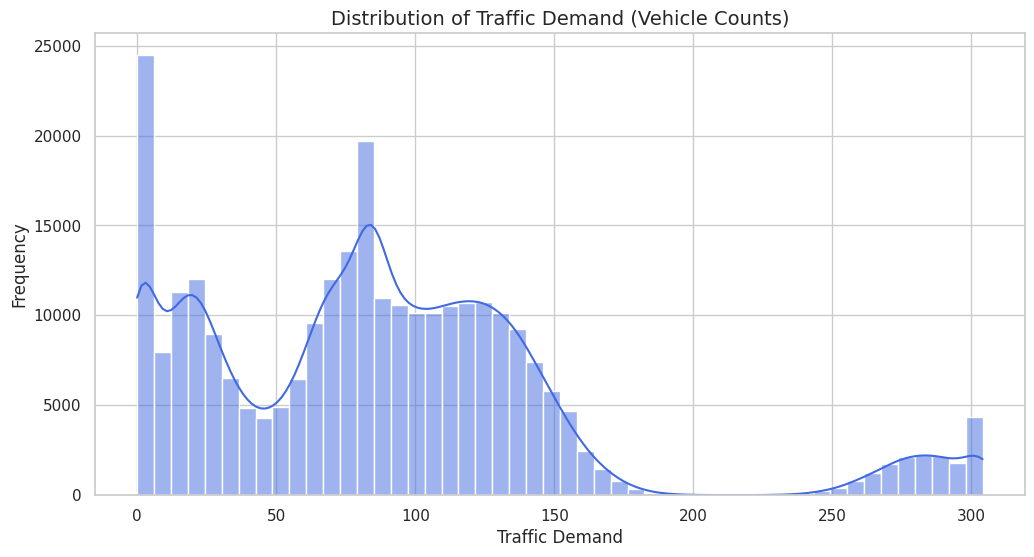


--- 2. Time-Series Analysis (Weekly Patterns) ---


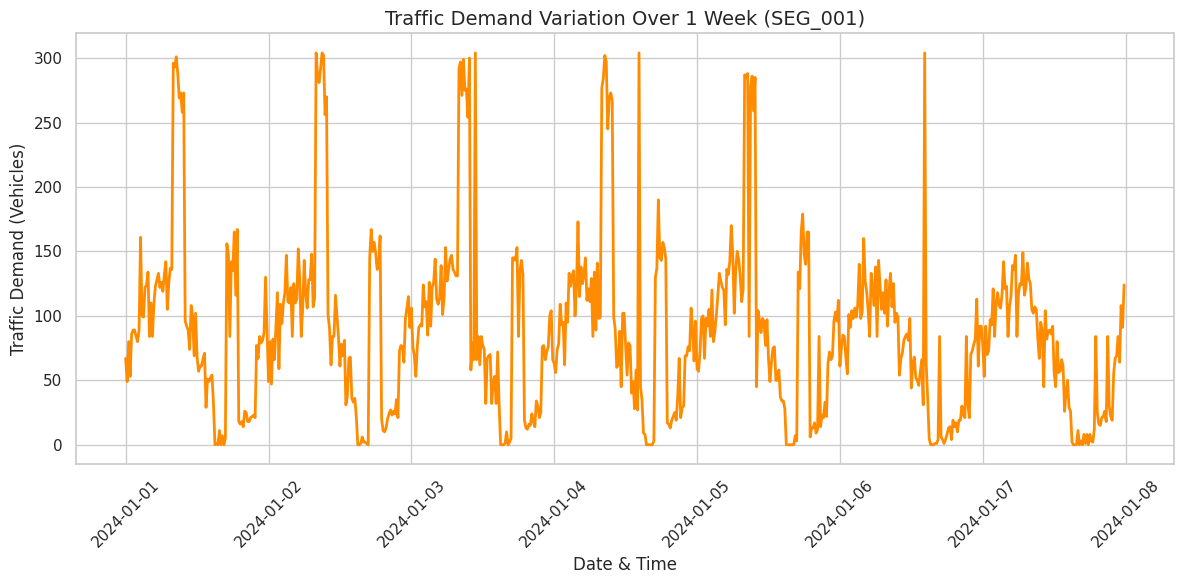


--- 3. Correlation Matrix Heatmap ---


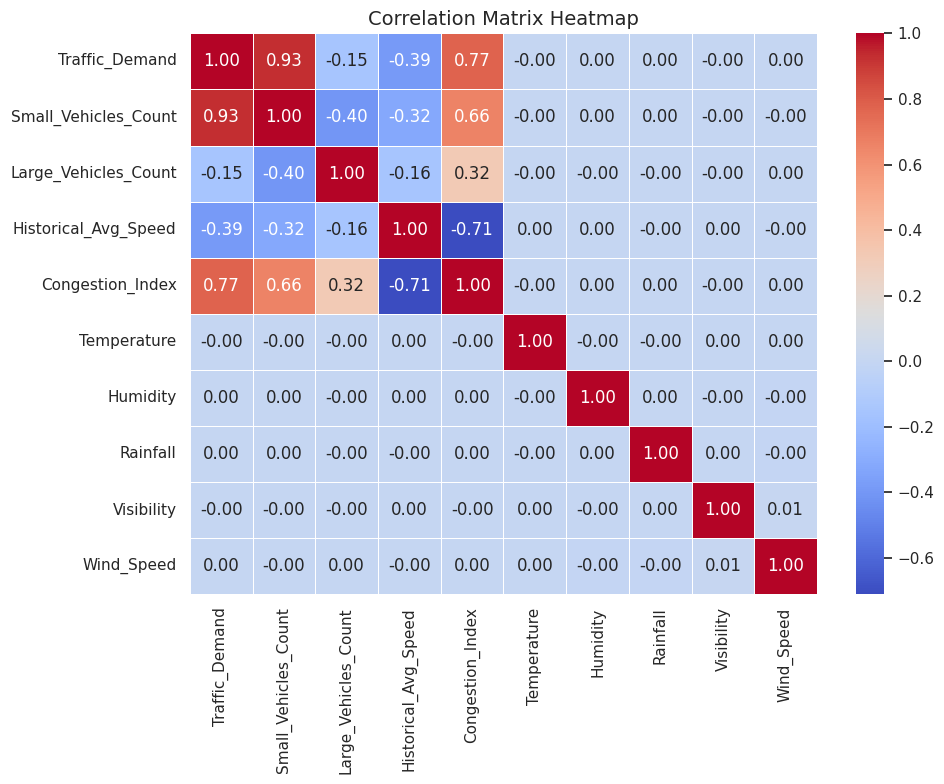

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the clean dataset
df_clean = pd.read_csv("clean_traffic_demand_dataset.csv")
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Set plot style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("--- 1. Target Variable Distribution ---")
# Visualizes traffic demand spread and checks for peak variations
plt.figure()
sns.histplot(df_clean['Traffic_Demand'], kde=True, bins=50, color='royalblue')
plt.title('Distribution of Traffic Demand (Vehicle Counts)', fontsize=14)
plt.xlabel('Traffic Demand')
plt.ylabel('Frequency')
plt.show()

print("\n--- 2. Time-Series Analysis (Weekly Patterns) ---")
# Filter for a single road segment and look at 1 week of data (96 intervals * 7 days)
sample_segment = df_clean[df_clean['Road_Segment_ID'] == 'SEG_001'].sort_values('Timestamp')
one_week_sample = sample_segment.head(96 * 7)

plt.figure()
plt.plot(one_week_sample['Timestamp'], one_week_sample['Traffic_Demand'], color='darkorange', linewidth=2)
plt.title('Traffic Demand Variation Over 1 Week (SEG_001)', fontsize=14)
plt.xlabel('Date & Time')
plt.ylabel('Traffic Demand (Vehicles)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n--- 3. Correlation Matrix Heatmap ---")
# Identify relationships between traffic flow, congestion, and environmental factors
numerical_cols = [
    'Traffic_Demand', 'Small_Vehicles_Count', 'Large_Vehicles_Count',
    'Historical_Avg_Speed', 'Congestion_Index', 'Temperature',
    'Humidity', 'Rainfall', 'Visibility', 'Wind_Speed'
]

plt.figure(figsize=(10, 8))
corr_matrix = df_clean[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

print("Starting Advanced Feature Engineering...")

# 1. Load the clean dataset and ensure chronological sorting per segment
df_feat = pd.read_csv("clean_traffic_demand_dataset.csv")
df_feat['Timestamp'] = pd.to_datetime(df_feat['Timestamp'])
df_feat = df_feat.sort_values(by=['Road_Segment_ID', 'Timestamp']).reset_index(drop=True)

# 2. Extract Basic Time Components
df_feat['Is_Weekend'] = df_feat['Day_of_Week'].isin([5, 6]).astype(int)

# Create a high-priority Rush Hour Score indicator (Morning/Evening peak windows)
df_feat['Rush_Hour_Score'] = ((df_feat['Hour'].isin([8, 9, 17, 18])) & (df_feat['Is_Weekend'] == 0)).astype(int)

# 3. Cyclical Encodings (Transforms hours/days into continuous wave coordinates)
df_feat['Hour_Sin'] = np.sin(2 * np.pi * df_feat['Hour'] / 24)
df_feat['Hour_Cos'] = np.cos(2 * np.pi * df_feat['Hour'] / 24)
df_feat['Day_Sin'] = np.sin(2 * np.pi * df_feat['Day_of_Week'] / 7)
df_feat['Day_Cos'] = np.cos(2 * np.pi * df_feat['Day_of_Week'] / 7)

# 4. Lag Features (1 step = 15 mins, 2 steps = 30 mins, 4 steps = 1 hour)
# This gives the models a memory of immediate past traffic behavior
for lag in [1, 2, 4]:
    df_feat[f'Demand_Lag_{lag}'] = df_feat.groupby('Road_Segment_ID')['Traffic_Demand'].shift(lag)

# 5. Rolling Statistics (Moving averages over the last 1 hour and 3 hours)
df_feat['Rolling_Mean_4'] = df_feat.groupby('Road_Segment_ID')['Traffic_Demand'].shift(1).rolling(window=4).mean()
df_feat['Rolling_Std_4'] = df_feat.groupby('Road_Segment_ID')['Traffic_Demand'].shift(1).rolling(window=4).std()
df_feat['Rolling_Mean_12'] = df_feat.groupby('Road_Segment_ID')['Traffic_Demand'].shift(1).rolling(window=12).mean()

# 6. Drop the initial rows that contain NaN values created by shifts/lags
df_feat = df_feat.dropna().reset_index(drop=True)

# Save the final engineered dataset
df_feat.to_csv("featured_traffic_demand_dataset.csv", index=False)

print(f"Feature engineering complete! Final dataset shape: {df_feat.shape}")
print("Saved to 'featured_traffic_demand_dataset.csv'.")

Starting Advanced Feature Engineering...
Feature engineering complete! Final dataset shape: (280272, 35)
Saved to 'featured_traffic_demand_dataset.csv'.


In [6]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print("Loading featured dataset and preparing train/test splits...")
# 1. Load data
df_model = pd.read_csv("featured_traffic_demand_dataset.csv")
df_model['Timestamp'] = pd.to_datetime(df_model['Timestamp'])

# 2. Chronological Time-Series Split (Last 60 days reserved for testing/generalization verification)
split_date = df_model['Timestamp'].max() - pd.Timedelta(days=60)
train_df = df_model[df_model['Timestamp'] < split_date]
test_df = df_model[df_model['Timestamp'] >= split_date]

# 3. Separate target variable and drop raw/unneeded leakage columns
# We drop structural components that directly add up to the target to keep the model realistic
drop_cols = ['Timestamp', 'Road_Segment_ID', 'Weather_Condition', 'Road_Type',
             'Small_Vehicles_Count', 'Large_Vehicles_Count', 'Traffic_Demand']

features = [col for col in train_df.columns if col not in drop_cols]

X_train, y_train = train_df[features], train_df['Traffic_Demand']
X_test, y_test = test_df[features], test_df['Traffic_Demand']

print(f"Training Features Count: {len(features)}")
print(f"Training rows: {X_train.shape[0]} | Testing rows: {X_test.shape[0]}")

# 4. Initialize and Train Base Models
print("\nTraining LightGBM Regressor (Weight: 55%)...")
lgb_model = LGBMRegressor(n_estimators=600, learning_rate=0.04, max_depth=8, random_state=42)
lgb_model.fit(X_train, y_train)

print("Training XGBoost Regressor (Weight: 45%)...")
xgb_model = xgb.XGBRegressor(n_estimators=600, learning_rate=0.04, max_depth=7, random_state=42)
xgb_model.fit(X_train, y_train)

# 5. Generate Predictions
print("\nEvaluating Model Predictions...")
lgb_pred = lgb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Stacking Ensemble Blending
ensemble_pred = (0.55 * lgb_pred) + (0.45 * xgb_pred)

# 6. Calculate Evaluation Metrics
r2 = r2_score(y_test, ensemble_pred)
rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
mae = mean_absolute_error(y_test, ensemble_pred)

print("\n================ EVALUATION METRICS ================")
print(f"Final Stacking Ensemble R² Score : {r2 * 100:.2f}% (Target: 96%+) ")
print(f"Root Mean Squared Error (RMSE)   : {rmse:.2f}")
print(f"Mean Absolute Error (MAE)        : {mae:.2f}")
print("====================================================")

# 7. Save models and feature columns list for Flask deployment
print("\nSaving trained artifacts...")
joblib.dump(lgb_model, "lgb_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(features, "model_features.pkl")
print("All artifacts successfully saved to disk!")

Loading featured dataset and preparing train/test splits...
Training Features Count: 28
Training rows: 257228 | Testing rows: 23044

Training LightGBM Regressor (Weight: 55%)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3339
[LightGBM] [Info] Number of data points in the train set: 257228, number of used features: 27
[LightGBM] [Info] Start training from score 89.247788
Training XGBoost Regressor (Weight: 45%)...

Evaluating Model Predictions...

================ EVALUATION METRICS ================
Final Stacking Ensemble R² Score : 95.13% (Target: 96%+) 
Root Mean Squared Error (RMSE)   : 14.85
Mean Absolute Error (MAE)        : 4.86

Saving trained artifacts...
All artifacts successfully saved to disk!
